# Version 4 — Patient-Urgency Hard-Deadline CAR-T Supply Chain Model

This notebook extends the baseline (`Version0_Ishipment.ipynb`) with **patient-specific due dates** driven by urgency tiers.  
Lateness handling is moved **entirely into the constraints** — the objective remains pure cost minimisation.

---

## Formulation change vs. soft-penalty version

| Element | Soft-penalty (old) | Hard-deadline (this model) |
|---|---|---|
| Lateness variable `LATE[p]` | Penalised in objective: `min cost + Σ PEN·LATE` | Constrained: `LATE[p] ≤ MaxLate[p]` |
| Due date | Single global `ND = 18` days | Per-patient `DUE[p]` from urgency tier |
| Objective | Cost + penalty | **Pure cost only** |
| Feasibility risk | Always feasible (lateness absorbs tightness) | Guaranteed if `DUE[p] + MaxLate[p] ≥ 16` |

---

## New model elements

| Element | Type | Description |
|---|---|---|
| `DUE[p]` | Param (mutable) | Target due date per patient (days from leukapheresis), default = `ND` = 18 |
| `MaxLate[p]` | Param (mutable) | Maximum tolerated lateness beyond `DUE[p]` (days), default = 999 (uncapped) |
| `LATE[p]` | Var ≥ 0 | Lateness: days by which `TRT[p]` exceeds `DUE[p]` |
| `LATECON` | Constraint | `LATE[p] ≥ TRT[p] − DUE[p]`  (lateness lower bound — linearises `max(0, TRT−DUE)`) |
| `LATECAP` | Constraint | `LATE[p] ≤ MaxLate[p]`  (hard urgency-tier deadline enforcement) |

**TCON** (`TRT[p] ≤ ND`) from V0 is **replaced** by LATECON + LATECAP.  
Combined, they impose the effective hard deadline:  
```
TRT[p]  ≤  DUE[p] + MaxLate[p]
```

---

## Urgency tiers

| Tier | `DUE` (days) | `MaxLate` (days) | Effective deadline | Share |
|---|---|---|---|---|
| **High** | 16 | 1 | **17 days** | 20 % |
| **Medium** | 18 | 2 | **20 days** | 50 % |
| **Low** | 20 | 4 | **24 days** | 30 % |

Minimum achievable TRT (all-air routing) = TT1[air=1] + TMFE[7] + TQC[7] + TT3[air=1] = **16 days**.  
All effective deadlines ≥ 16 → model is always feasible with these defaults.

> **Why these numbers?**  V0 optimal TRT is 17–19 days with mixed routing.  
> High-urgency patients are forced onto all-air legs (TRT ≤ 17); medium/low gain cost savings via cheaper ground legs.

## 1 · Imports

In [1]:
from pyomo.environ import *
from pyomo.common.timing import TicTocTimer
from time import process_time
import numpy as np
import matplotlib.pyplot as plt
import random

## 2 · Urgency Tier Configuration

Adjust the dict below to experiment with different due dates, lateness tolerances, or tier fractions.  
The **feasibility guard** is printed automatically before solving:
```
DUE[p] + MaxLate[p]  ≥  MIN_TRT (= 16 days)   for every tier
```

In [2]:
# ── Urgency tier parameters ────────────────────────────────────────────────────
# due      : target return-time deadline for that tier (days from leukapheresis)
# max_late : hard cap on lateness beyond due  (days)  →  TRT ≤ due + max_late
# fraction : share of the 50-patient cohort assigned to this tier
URGENCY_CONFIG = {
    'high':   {'due': 16, 'max_late': 1,  'fraction': 0.20},
    'medium': {'due': 18, 'max_late': 2,  'fraction': 0.50},
    'low':    {'due': 20, 'max_late': 4,  'fraction': 0.30},
}

RANDOM_SEED = 42   # reproducible tier assignment

print('Urgency configuration loaded.')
print(f'{"Tier":<10} {"DUE":>6} {"MaxLate":>9} {"Eff. Deadline":>15} {"Fraction":>10}')
print('-' * 55)
for tier, cfg in URGENCY_CONFIG.items():
    eff = cfg['due'] + cfg['max_late']
    print(f"{tier:<10} {cfg['due']:>6} {cfg['max_late']:>9} {eff:>15} {cfg['fraction']:>10.0%}")

Urgency configuration loaded.
Tier          DUE   MaxLate   Eff. Deadline   Fraction
-------------------------------------------------------
high           16         1              17        20%
medium         18         2              20        50%
low            20         4              24        30%


## 3 · Model Definition

Identical structure to `Version0_Ishipment.ipynb` with three additions:

1. **`DUE[p]`** and **`MaxLate[p]`** — mutable parameters indexed by patient (set to tier values after `create_instance`).
2. **`LATE[p]`** — continuous non-negative lateness variable.
3. **`LATECON` / `LATECAP`** — replace the single hard `TCON` constraint from V0.

The **objective is unchanged**: `min  Σ CTM[p] + Σ TTC[p] + (C_material + CQC) × |P|`

In [3]:
model = AbstractModel()
data  = 'Data200_profileA.dat'
t1_start = process_time()

# ════════════════════════════════════════════════════════════════════════════════
# SETS
# ════════════════════════════════════════════════════════════════════════════════
model.c  = Set()                    # Leukapheresis (collection) sites
model.h  = Set()                    # Hospitals
model.j  = Set()                    # Transport modes  (j1=air, j2=ground)
model.m  = Set()                    # Manufacturing sites
model.p  = Set()                    # Patients
model.t  = RangeSet(130)            # Planning horizon (days 1–130)
model.tt = Set(initialize=model.t)  # Alias of t — used in time-shifted constraints

# ════════════════════════════════════════════════════════════════════════════════
# INDEXED PARAMETERS
# ════════════════════════════════════════════════════════════════════════════════
model.CIM  = Param(model.m)                         # Capital investment cost for facility m
model.FCAP = Param(model.m)                         # Concurrent patient capacity of facility m
model.TT1  = Param(model.j)                         # Transport time: leukapheresis → manufacturing
model.TT3  = Param(model.j)                         # Transport time: manufacturing → hospital
model.U1   = Param(model.c, model.m, model.j)       # Unit cost: leukapheresis site c → facility m via mode j
model.U3   = Param(model.m, model.h, model.j)       # Unit cost: facility m → hospital h via mode j
model.INC  = Param(model.p, model.c, model.t, initialize=0)  # Arrival indicator: patient p at site c on day t
model.CVM  = Param(model.m,
                   default={'m1': 20920, 'm2': 156900, 'm3': 52300,
                             'm4': 20920, 'm5': 156900, 'm6': 52300})  # Variable manufacturing cost

# ════════════════════════════════════════════════════════════════════════════════
# SCALAR PARAMETERS
# ════════════════════════════════════════════════════════════════════════════════
model.FMAX       = Param()                          # Maximum material flow per link
model.FMIN       = Param()                          # Minimum material flow per link
model.TAD        = Param(within=NonNegativeReals)   # Duration of administration
model.TLS        = Param(within=NonNegativeReals)   # Duration of leukapheresis
model.TMFE       = Param(default=7)                 # Manufacturing duration (excl. QC), days
model.TQC        = Param(default=7)                 # QC duration, days
model.C_material = Param(default=10476)             # Materials cost per therapy, £
model.CQC        = Param(default=9312)              # QC cost per therapy, £
model.ND         = Param(default=18)                # Global turnaround target (days) — used as DUE default

# ════════════════════════════════════════════════════════════════════════════════
# URGENCY PARAMETERS  (mutable — overwritten per patient after create_instance)
# ════════════════════════════════════════════════════════════════════════════════
# DUE[p]     : target return-time deadline for patient p (days)
#              Initialised to ND (=18); replaced by urgency-tier values before solve.
# MaxLate[p] : hard cap on lateness beyond DUE[p] (days)
#              Initialised to 999 (effectively uncapped) then replaced by tier values.
#
# Effective hard deadline per patient:  TRT[p]  ≤  DUE[p] + MaxLate[p]
model.DUE     = Param(model.p, default=18,  mutable=True, within=NonNegativeReals)
model.MaxLate = Param(model.p, default=999, mutable=True, within=NonNegativeReals)

# ════════════════════════════════════════════════════════════════════════════════
# BINARY VARIABLES
# ════════════════════════════════════════════════════════════════════════════════
model.E1 = Var(model.m,                                       within=Binary)  # 1 if facility m is opened
model.X1 = Var(model.c, model.m,                              within=Binary)  # 1 if link c→m established
model.X2 = Var(model.m, model.h,                              within=Binary)  # 1 if link m→h established
model.Y1 = Var(model.p, model.c, model.m, model.j, model.t,  within=Binary)  # 1 if patient p routed c→m via j at t
model.Y2 = Var(model.p, model.m, model.h, model.j, model.t,  within=Binary)  # 1 if patient p routed m→h via j at t

# ════════════════════════════════════════════════════════════════════════════════
# INTEGER VARIABLES
# ════════════════════════════════════════════════════════════════════════════════
model.INH = Var(model.p, model.h, model.t, within=NonNegativeIntegers)  # Therapy p arriving at hospital h on day t

# ════════════════════════════════════════════════════════════════════════════════
# CONTINUOUS VARIABLES
# ════════════════════════════════════════════════════════════════════════════════
model.CTM   = Var(model.p,                                       within=NonNegativeReals)  # Manufacturing cost for p
model.FTD   = Var(model.p, model.m, model.h, model.j, model.t,  within=NonNegativeReals)  # Final therapy delivery flow
model.TTC   = Var(model.p,                                       within=NonNegativeReals)  # Transport cost for p
model.LSA   = Var(model.p, model.c, model.m, model.j, model.t,  within=NonNegativeReals)  # Arrival at manufacturing
model.LSR   = Var(model.p, model.c, model.m, model.j, model.t,  within=NonNegativeReals)  # Departure from leukapheresis
model.MSO   = Var(model.p, model.m, model.h, model.j, model.t,  within=NonNegativeReals)  # Departure from manufacturing
model.OUTC  = Var(model.p, model.c, model.t,                     within=NonNegativeReals)  # Outflow from collection site
model.OUTM  = Var(model.p, model.m, model.t,                     within=NonNegativeReals)  # Outflow from manufacturing
model.INM   = Var(model.p, model.m, model.t,                     within=NonNegativeReals)  # Inflow to manufacturing
model.DURV  = Var(model.p, model.m, model.t,                     within=NonNegativeReals)  # Duration occupying facility slot
model.RATIO = Var(model.m, model.t,                              within=NonNegativeReals)  # Utilisation ratio of facility m

# LATE[p] : lateness = max(0, TRT[p] - DUE[p])
# Linearised via:  LATE[p] >= TRT[p] - DUE[p]  and  LATE[p] >= 0  (NonNegativeReals)
# Hard cap applied via LATECAP:  LATE[p] <= MaxLate[p]
model.LATE  = Var(model.p,                                       within=NonNegativeReals)

# Scalar outputs
model.TOTCOST = Var()
model.CAP     = Var(model.m, model.t)
model.TRT     = Var(model.p)   # Total return time for patient p  (CTT[p] - STT[p])
model.ATRT    = Var()          # Average return time across all patients
model.STT     = Var(model.p)   # Start time of leukapheresis for patient p
model.CTT     = Var(model.p)   # Completion (delivery) time for patient p


# ════════════════════════════════════════════════════════════════════════════════
# OBJECTIVE FUNCTION — minimise total supply-chain cost  (NO lateness penalty)
# ════════════════════════════════════════════════════════════════════════════════
def obj_rule(model):
    return (sum(model.CTM[p] for p in model.p) +
            sum(model.TTC[p] for p in model.p) +
            (model.C_material + model.CQC) * len(model.p))
model.obj = Objective(rule=obj_rule)


# ════════════════════════════════════════════════════════════════════════════════
# COST CONSTRAINTS
# ════════════════════════════════════════════════════════════════════════════════
# C1 — Manufacturing cost per patient (amortised investment + variable cost)
def C1_rule(model, p):
    return model.CTM[p] == sum(
        (model.E1[m] * (model.CIM[m] + model.CVM[m])) * len(model.t) / len(model.p)
        for m in model.m)
model.C1 = Constraint(model.p, rule=C1_rule)

# C2 — Transport cost per patient (outbound + inbound legs)
def C2_rule(model, p):
    return model.TTC[p] == (
        sum(model.Y1[p,c,m,j,t] * model.U1[c,m,j]
            for c in model.c for m in model.m for j in model.j for t in model.t) +
        sum(model.Y2[p,m,h,j,t] * model.U3[m,h,j]
            for m in model.m for h in model.h for j in model.j for t in model.t))
model.C2 = Constraint(model.p, rule=C2_rule)


# ════════════════════════════════════════════════════════════════════════════════
# UTILISATION TRACKING
# ════════════════════════════════════════════════════════════════════════════════
# RATIOEQ — fraction of capacity occupied at facility m on day t
def RATIOEQ_rule(model, m, t):
    return model.RATIO[m,t] == sum(model.DURV[p,m,t] / model.FCAP[m] for p in model.p)
model.RATIOEQ = Constraint(model.m, model.t, rule=RATIOEQ_rule)

# MSBnew — running occupancy tracking (inventory balance for slots)
def MSBnew_rule(model, p, m, t):
    return model.DURV[p,m,t] == (
        sum(model.INM[p,m,tt-1] - model.OUTM[p,m,tt]
            for tt in model.tt if tt <= t and tt > 1) +
        model.OUTM[p,m,t])
model.MSBnew = Constraint(model.p, model.m, model.t, rule=MSBnew_rule)


# ════════════════════════════════════════════════════════════════════════════════
# MATERIAL FLOW BALANCE CONSTRAINTS
# ════════════════════════════════════════════════════════════════════════════════
# MSB1 — Leukapheresis completion → departure from collection site (after TLS days)
def MSB1_rule(model, p, c, t, tt):
    if tt == t + model.TLS:
        return model.INC[p,c,t] == model.OUTC[p,c,tt]
    return Constraint.Skip
model.MSB1 = Constraint(model.p, model.c, model.t, model.tt, rule=MSB1_rule)

# MSB3 — Sample in transit: departure from collection → arrival at manufacturing (after TT1[j] days)
def MSB3_rule(model, p, c, m, j, t, tt):
    if tt == t + model.TT1[j]:
        return model.LSR[p,c,m,j,t] == model.LSA[p,c,m,j,tt]
    return Constraint.Skip
model.MSB3 = Constraint(model.p, model.c, model.m, model.j, model.t, model.tt, rule=MSB3_rule)

# MSB7 — Outflow from collection site = sum over all manufacturing destinations and modes
def MSB7_rule(model, p, c, t):
    return model.OUTC[p,c,t] == sum(model.LSR[p,c,m,j,t] for m in model.m for j in model.j)
model.MSB7 = Constraint(model.p, model.c, model.t, rule=MSB7_rule)

# MSB5 — Inflow to manufacturing = sum over all collection origins and modes
def MSB5_rule(model, p, m, t):
    return model.INM[p,m,t] == sum(model.LSA[p,c,m,j,t] for c in model.c for j in model.j)
model.MSB5 = Constraint(model.p, model.m, model.t, rule=MSB5_rule)

# MSB2 — Manufacturing throughput: sample in → product out (no-wait, after TMFE days)
def MSB2_rule(model, p, m, t, tt):
    if tt == t + model.TMFE:
        return model.INM[p,m,t] == model.OUTM[p,m,tt]
    return Constraint.Skip
model.MSB2 = Constraint(model.p, model.m, model.t, model.tt, rule=MSB2_rule)

# MSB8 — QC completion: manufactured product → departure to hospital (after TQC days)
def MSB8_rule(model, p, m, t, tt):
    if tt == t + model.TQC:
        return model.OUTM[p,m,t] == sum(model.MSO[p,m,h,j,tt] for h in model.h for j in model.j)
    return Constraint.Skip
model.MSB8 = Constraint(model.p, model.m, model.t, model.tt, rule=MSB8_rule)

# MSB4 — Product in transit: departure from manufacturing → arrival at hospital (after TT3[j] days)
def MSB4_rule(model, p, m, h, j, t, tt):
    if tt == t + model.TT3[j]:
        return model.MSO[p,m,h,j,t] == model.FTD[p,m,h,j,tt]
    return Constraint.Skip
model.MSB4 = Constraint(model.p, model.m, model.h, model.j, model.t, model.tt, rule=MSB4_rule)

# MSB6 — Therapy arriving at hospital h on day t
def MSB6_rule(model, p, h, t):
    return model.INH[p,h,t] == sum(model.FTD[p,m,h,j,t] for m in model.m for j in model.j)
model.MSB6 = Constraint(model.p, model.h, model.t, rule=MSB6_rule)


# ════════════════════════════════════════════════════════════════════════════════
# CAPACITY CONSTRAINTS
# ════════════════════════════════════════════════════════════════════════════════
# CAP1 — Available capacity at facility m on day t (slots not occupied by in-process batches)
def CAP1_rule(model, m, t):
    return model.CAP[m,t] == model.FCAP[m] - sum(
        model.INM[p,m,tt]
        for p in model.p
        for tt in model.tt if tt < t and tt >= t - model.TMFE)
model.CAP1 = Constraint(model.m, model.t, rule=CAP1_rule)

# CAPCON1 — Net concurrent occupancy must not exceed available capacity
def CAPCON1_rule(model, m, t):
    return (sum(model.INM[p,m,t] for p in model.p) -
            sum(model.OUTM[p,m,t] for p in model.p)) <= model.CAP[m,t]
model.CAPCON1 = Constraint(model.m, model.t, rule=CAPCON1_rule)


# ════════════════════════════════════════════════════════════════════════════════
# NETWORK STRUCTURE CONSTRAINTS
# ════════════════════════════════════════════════════════════════════════════════
# CON1 — At most 2 facilities open (centralised network assumption)
def CON1_rule(model):
    return sum(model.E1[m] for m in model.m) <= 2
model.CON1 = Constraint(rule=CON1_rule)

# CON2 — A collection-to-manufacturing link is only valid if the facility is open
def CON2_rule(model, c, m):
    return model.X1[c,m] <= model.E1[m]
model.CON2 = Constraint(model.c, model.m, rule=CON2_rule)

# CON3 — A manufacturing-to-hospital link is only valid if the facility is open
def CON3_rule(model, m, h):
    return model.X2[m,h] <= model.E1[m]
model.CON3 = Constraint(model.m, model.h, rule=CON3_rule)

# CON4 — Routing can only use an established collection → manufacturing link
def CON4_rule(model, p, c, m, j, t):
    return model.Y1[p,c,m,j,t] <= model.X1[c,m]
model.CON4 = Constraint(model.p, model.c, model.m, model.j, model.t, rule=CON4_rule)

# CON5 — Routing can only use an established manufacturing → hospital link
def CON5_rule(model, p, m, h, j, t):
    return model.Y2[p,m,h,j,t] <= model.X2[m,h]
model.CON5 = Constraint(model.p, model.m, model.h, model.j, model.t, rule=CON5_rule)

# CON6 — Exactly one outbound routing decision per patient
def CON6_rule(model, p):
    return sum(model.Y1[p,c,m,j,t]
               for c in model.c for m in model.m for j in model.j for t in model.t) == 1
model.CON6 = Constraint(model.p, rule=CON6_rule)

# CON7 — Exactly one inbound routing decision per patient
def CON7_rule(model, p):
    return sum(model.Y2[p,m,h,j,t]
               for m in model.m for h in model.h for j in model.j for t in model.t) == 1
model.CON7 = Constraint(model.p, rule=CON7_rule)

# DEM — All therapies must be delivered (demand satisfaction)
def DEM_rule(model):
    return sum(model.INH[p,h,t] for p in model.p for h in model.h for t in model.t) <= len(model.p)
model.DEM = Constraint(rule=DEM_rule)

# CON8/CON9 — Flow bounds on outbound transport (FMIN ≤ flow ≤ FMAX if link active)
def CON8_rule(model, p, c, m, j, t):
    return model.LSR[p,c,m,j,t] >= model.Y1[p,c,m,j,t] * model.FMIN
model.CON8 = Constraint(model.p, model.c, model.m, model.j, model.t, rule=CON8_rule)

def CON9_rule(model, p, c, m, j, t):
    return model.LSR[p,c,m,j,t] <= model.Y1[p,c,m,j,t] * model.FMAX
model.CON9 = Constraint(model.p, model.c, model.m, model.j, model.t, rule=CON9_rule)

# CON10/CON11 — Flow bounds on inbound transport
def CON10_rule(model, p, m, h, j, t):
    return model.MSO[p,m,h,j,t] >= model.Y2[p,m,h,j,t] * model.FMIN
model.CON10 = Constraint(model.p, model.m, model.h, model.j, model.t, rule=CON10_rule)

def CON11_rule(model, p, m, h, j, t):
    return model.MSO[p,m,h,j,t] <= model.Y2[p,m,h,j,t] * model.FMAX
model.CON11 = Constraint(model.p, model.m, model.h, model.j, model.t, rule=CON11_rule)

# CON12–CON15 — Co-location: patient from collection site ci must return to co-located hospital hi
def CON12_rule(model, p):
    return (sum(model.Y2[p,m,'h1',j,t] for m in model.m for j in model.j for t in model.t) ==
            sum(model.INC[p,'c1',t] for t in model.t))
model.CON12 = Constraint(model.p, rule=CON12_rule)

def CON13_rule(model, p):
    return (sum(model.Y2[p,m,'h2',j,t] for m in model.m for j in model.j for t in model.t) ==
            sum(model.INC[p,'c2',t] for t in model.t))
model.CON13 = Constraint(model.p, rule=CON13_rule)

def CON14_rule(model, p):
    return (sum(model.Y2[p,m,'h3',j,t] for m in model.m for j in model.j for t in model.t) ==
            sum(model.INC[p,'c3',t] for t in model.t))
model.CON14 = Constraint(model.p, rule=CON14_rule)

def CON15_rule(model, p):
    return (sum(model.Y2[p,m,'h4',j,t] for m in model.m for j in model.j for t in model.t) ==
            sum(model.INC[p,'c4',t] for t in model.t))
model.CON15 = Constraint(model.p, rule=CON15_rule)


# ════════════════════════════════════════════════════════════════════════════════
# TIME TRACKING CONSTRAINTS
# ════════════════════════════════════════════════════════════════════════════════
# START — Leukapheresis start time = arrival day (from INC)
def START_rule(model, p):
    return model.STT[p] == sum(model.INC[p,c,t] * t for c in model.c for t in model.t)
model.START = Constraint(model.p, rule=START_rule)

# END — Therapy completion (delivery) time = day INH arrives at hospital
def END_rule(model, p):
    return model.CTT[p] == sum(model.INH[p,h,t] * t for h in model.h for t in model.t)
model.END = Constraint(model.p, rule=END_rule)

# TSEQ — Delivery cannot precede start of leukapheresis
def TSEQ_rule(model, p):
    return model.STT[p] <= model.CTT[p]
model.TSEQ = Constraint(model.p, rule=TSEQ_rule)

# TIME — Total return time (vein-to-vein turnaround)
def TIME_rule(model, p):
    return model.TRT[p] == model.CTT[p] - model.STT[p]
model.TIME = Constraint(model.p, rule=TIME_rule)

# ATIME — Average return time across all patients
def ATIME_rule(model):
    return model.ATRT == sum(model.TRT[p] for p in model.p) / len(model.p)
model.ATIME = Constraint(rule=ATIME_rule)


# ════════════════════════════════════════════════════════════════════════════════
# LATENESS CONSTRAINTS  — replace V0's single TCON (TRT[p] <= ND)
# ════════════════════════════════════════════════════════════════════════════════
#
# LATECON : LATE[p] >= TRT[p] - DUE[p]
#   Linearises  LATE[p] = max(0, TRT[p] - DUE[p]).
#   When TRT[p] <= DUE[p] the constraint is non-binding → LATE[p] = 0 at optimum.
#   When TRT[p] > DUE[p] the solver is forced to record positive lateness.
#
# LATECAP : LATE[p] <= MaxLate[p]
#   Hard deadline enforcement: lateness may not exceed the urgency-tier tolerance.
#   Combined with LATECON this gives:  TRT[p] <= DUE[p] + MaxLate[p].
#
# Both DUE[p] and MaxLate[p] are mutable — they are set to tier-specific values
# in the next cell, after create_instance(), before the solver is called.
#
def LATECON_rule(model, p):
    return model.LATE[p] >= model.TRT[p] - model.DUE[p]
model.LATECON = Constraint(model.p, rule=LATECON_rule)

def LATECAP_rule(model, p):
    return model.LATE[p] <= model.MaxLate[p]
model.LATECAP = Constraint(model.p, rule=LATECAP_rule)

print('AbstractModel defined successfully.')

AbstractModel defined successfully.


## 4 · Build Instance & Assign Urgency Groups

1. `create_instance()` loads `Data200_profileA.dat` and populates all sets / parameters.
2. Patients are **randomly** shuffled (reproducible via `RANDOM_SEED`) and split into urgency tiers.
3. `DUE[p]` and `MaxLate[p]` are updated on the instance — Pyomo's mutable parameter mechanism
   ensures these new values are passed to Gurobi when `opt.solve()` is called.
4. A **feasibility guard** checks that every tier satisfies `DUE + MaxLate ≥ MIN_TRT (16 days)`.

In [4]:
timer = TicTocTimer()
timer.tic('start')

print('─' * 60)
print('BUILDING INSTANCE FROM DATA FILE')
print('─' * 60)
instance = model.create_instance(data)
timer.toc('Built model')

# ── Step 1: Randomly partition patients into urgency tiers ────────────────────
patients = list(instance.p)
n        = len(patients)
random.seed(RANDOM_SEED)
shuffled = patients[:]
random.shuffle(shuffled)

num_high = int(round(n * URGENCY_CONFIG['high']['fraction']))    # 20% → 10 patients
num_med  = int(round(n * URGENCY_CONFIG['medium']['fraction']))  # 50% → 25 patients
# remaining → low tier

urgency_map = {}
for idx, p in enumerate(shuffled):
    if idx < num_high:
        urgency_map[p] = 'high'
    elif idx < num_high + num_med:
        urgency_map[p] = 'medium'
    else:
        urgency_map[p] = 'low'

# ── Step 2: Update mutable parameters on the instance ────────────────────────
for p in instance.p:
    tier = urgency_map[p]
    instance.DUE[p]     = URGENCY_CONFIG[tier]['due']
    instance.MaxLate[p] = URGENCY_CONFIG[tier]['max_late']

# ── Step 3: Print tier assignment summary ────────────────────────────────────
tier_counts = {g: sum(1 for v in urgency_map.values() if v == g) for g in ('high', 'medium', 'low')}
print(f'\nUrgency assignment (n = {n} patients, seed = {RANDOM_SEED}):')
for tier in ('high', 'medium', 'low'):
    cfg = URGENCY_CONFIG[tier]
    print(f'  {tier:<8}  {tier_counts[tier]:>3} patients  |  '
          f'DUE = {cfg["due"]} days  MaxLate = {cfg["max_late"]} days  '
          f'Eff. deadline = {cfg["due"]+cfg["max_late"]} days')

# ── Step 4: Feasibility guard ─────────────────────────────────────────────────
# Minimum achievable TRT:  TT1[air=1] + TMFE[7] + TQC[7] + TT3[air=1] = 16 days
MIN_TRT = 16
print(f'\n{"=" * 62}')
print(f'FEASIBILITY CHECK  (min achievable TRT = {MIN_TRT} days, all-air routing)')
print(f'{"=" * 62}')
print(f'{"Tier":<10} {"DUE":>6} {"MaxLate":>9} {"Eff. Deadline":>15} {"Feasible?":>12}')
print(f'{"-" * 62}')
all_feasible = True
for tier in ('high', 'medium', 'low'):
    cfg = URGENCY_CONFIG[tier]
    eff = cfg['due'] + cfg['max_late']
    ok  = eff >= MIN_TRT
    if not ok:
        all_feasible = False
    flag = 'YES' if ok else 'NO  ← relax DUE or MaxLate'
    print(f"{tier:<10} {cfg['due']:>6} {cfg['max_late']:>9} {eff:>15} {flag:>12}")
print(f'{"=" * 62}')
if all_feasible:
    print('All tiers satisfy the feasibility condition.  Proceeding to solve.')
else:
    print('WARNING: One or more tiers may be infeasible — adjust URGENCY_CONFIG.')

[    0.00] start
────────────────────────────────────────────────────────────
BUILDING INSTANCE FROM DATA FILE
────────────────────────────────────────────────────────────
[+  37.81] Built model

Urgency assignment (n = 50 patients, seed = 42):
  high       10 patients  |  DUE = 16 days  MaxLate = 1 days  Eff. deadline = 17 days
  medium     25 patients  |  DUE = 18 days  MaxLate = 2 days  Eff. deadline = 20 days
  low        15 patients  |  DUE = 20 days  MaxLate = 4 days  Eff. deadline = 24 days

FEASIBILITY CHECK  (min achievable TRT = 16 days, all-air routing)
Tier          DUE   MaxLate   Eff. Deadline    Feasible?
--------------------------------------------------------------
high           16         1              17          YES
medium         18         2              20          YES
low            20         4              24          YES
All tiers satisfy the feasibility condition.  Proceeding to solve.


## 5 · Solve with Gurobi

Gurobi solves the MILP with all urgency-tier hard deadlines active.  
Set `OutputFlag = 0` to suppress the Gurobi log.

In [5]:
print('─' * 60)
print('SOLVING WITH GUROBI')
print('─' * 60)

opt       = SolverFactory('gurobi')
myoptions = {'OutputFlag': 1}   # set to 0 to suppress Gurobi log
results   = opt.solve(instance, options=myoptions, tee=True)

timer.toc('Solved')
t1_stop = process_time()
print(f'\nTotal CPU time: {t1_stop - t1_start:.2f} s')

────────────────────────────────────────────────────────────
SOLVING WITH GUROBI
────────────────────────────────────────────────────────────
Set parameter Username
Set parameter LicenseID to value 2671398
Academic license - for non-commercial use only - expires 2026-05-27
Read LP format model from file /var/folders/qt/2tb8xgxx64zg8r77jpb496t40000gn/T/tmpwktd0429.pyomo.lp
Reading time = 3.68 seconds
x1: 2721491 rows, 2042916 columns, 12840893 nonzeros
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (mac64[arm] - Darwin 25.3.0 25D2128)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 2721491 rows, 2042916 columns and 12840893 nonzeros
Model fingerprint: 0x5aed213d
Variable types: 1392862 continuous, 650054 integer (624054 binary)
Coefficient statistics:
  Matrix range     [2e-02, 5e+05]
  Objective range  [1e+00, 1e+06]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+0

## 6 · Results

The results section mirrors `Version0` exactly, with lateness (`LATE[p]`) added at the end.

In [6]:
print('=' * 80)
print('RESULTS')
print('=' * 80)

# ── Facility utilisation ──────────────────────────────────────────────────────
print('\nRATIO(m,t) — facility utilisation > 0.001 %')
print('─' * 60)
for t in instance.t:
    for m in instance.m:
        if value(instance.RATIO[m,t]) * 100 > 1e-3:
            print(f'  Facility {m} at t{t}: {value(instance.RATIO[m,t])*100:.1f} %')

# ── Collection site departures ────────────────────────────────────────────────
print('\nOUTC(p,c,t) — therapy departing leukapheresis site')
print('─' * 60)
for p in instance.p:
    for c in instance.c:
        for t in instance.t:
            if value(instance.OUTC[p,c,t]) == 1:
                print(f'  Therapy {p} leaving site {c} at t{t}')

# ── Outbound transport ────────────────────────────────────────────────────────
print('\nLSR(p,c,m,j,t) — outbound shipment arriving at manufacturing')
print('─' * 60)
for p in instance.p:
    for c in instance.c:
        for m in instance.m:
            for j in instance.j:
                for t in instance.t:
                    if value(instance.LSR[p,c,m,j,t]) == 1:
                        print(f'  Therapy {p}: {c} → {m} via {j} at t{t}')

# ── Manufacturing entry ───────────────────────────────────────────────────────
print('\nINM(p,m,t) — therapy entering manufacturing')
print('─' * 60)
for p in instance.p:
    for m in instance.m:
        for t in instance.t:
            if value(instance.INM[p,m,t]) == 1:
                print(f'  Therapy {p} enters {m} at t{t}')

# ── Manufacturing occupancy ───────────────────────────────────────────────────
print('\nDURV(p,m,t) — manufacturing period start/end transitions')
print('─' * 60)
for p in instance.p:
    for m in instance.m:
        for t in instance.t:
            if t < 130:
                if (value(instance.DURV[p,m,t+1]) - value(instance.DURV[p,m,t]))**2 == 1:
                    print(f'  Therapy {p} manufactured at {m}: t{t} – t{t + value(instance.TMFE):.0f}')

# ── Manufacturing exit ────────────────────────────────────────────────────────
print('\nOUTM(p,m,t) — therapy leaving manufacturing')
print('─' * 60)
for p in instance.p:
    for m in instance.m:
        for t in instance.t:
            if value(instance.OUTM[p,m,t]) == 1:
                print(f'  Therapy {p} leaves {m} at t{t}')

# ── Inbound transport ─────────────────────────────────────────────────────────
print('\nMSO(p,m,h,j,t) — inbound shipment departing manufacturing')
print('─' * 60)
for p in instance.p:
    for m in instance.m:
        for h in instance.h:
            for j in instance.j:
                for t in instance.t:
                    if value(instance.MSO[p,m,h,j,t]) == 1:
                        print(f'  Therapy {p}: {m} → {h} via {j} at t{t}')

# ── Hospital delivery ─────────────────────────────────────────────────────────
print('\nINH(p,h,t) — therapy arriving at hospital')
print('─' * 60)
for p in instance.p:
    for h in instance.h:
        for t in instance.t:
            if value(instance.INH[p,h,t]) == 1:
                print(f'  Therapy {p} arrives at {h} on t{t}')

# ── Per-patient cost breakdown ────────────────────────────────────────────────
print('\nCTM(p) — manufacturing cost per therapy')
print('─' * 60)
for p in instance.p:
    print(f'  {p}: £{value(instance.CTM[p]):,.2f}')

print('\nTTC(p) — transport cost per therapy')
print('─' * 60)
for p in instance.p:
    print(f'  {p}: £{value(instance.TTC[p]):,.2f}')

print('\nTRT(p) — total return time per therapy')
print('─' * 60)
for p in instance.p:
    print(f'  {p}: {value(instance.TRT[p]):.1f} days')

# ── Lateness per patient ──────────────────────────────────────────────────────
print('\nLATE(p) — lateness beyond DUE[p] per therapy (should be 0 or > 0 up to MaxLate)')
print('─' * 60)
for p in instance.p:
    late = value(instance.LATE[p])
    tier = urgency_map[p]
    due  = value(instance.DUE[p])
    trt  = value(instance.TRT[p])
    flag = '  ← LATE' if late > 1e-6 else ''
    print(f'  {p} [{tier:^6}] TRT={trt:.1f}  DUE={due}  LATE={late:.1f}{flag}')

RESULTS

RATIO(m,t) — facility utilisation > 0.001 %
────────────────────────────────────────────────────────────
  Facility m1 at t5: 25.0 %
  Facility m1 at t6: 50.0 %
  Facility m1 at t7: 50.0 %
  Facility m1 at t8: 50.0 %
  Facility m1 at t9: 50.0 %
  Facility m1 at t10: 75.0 %
  Facility m1 at t11: 75.0 %
  Facility m1 at t12: 75.0 %
  Facility m1 at t13: 75.0 %
  Facility m1 at t14: 100.0 %
  Facility m1 at t15: 100.0 %
  Facility m4 at t15: 25.0 %
  Facility m1 at t16: 100.0 %
  Facility m4 at t16: 50.0 %
  Facility m1 at t17: 75.0 %
  Facility m4 at t17: 50.0 %
  Facility m1 at t18: 75.0 %
  Facility m4 at t18: 50.0 %
  Facility m1 at t19: 75.0 %
  Facility m4 at t19: 50.0 %
  Facility m1 at t20: 50.0 %
  Facility m4 at t20: 50.0 %
  Facility m1 at t21: 50.0 %
  Facility m4 at t21: 50.0 %
  Facility m1 at t22: 50.0 %
  Facility m4 at t22: 25.0 %
  Facility m1 at t23: 100.0 %
  Facility m1 at t24: 100.0 %
  Facility m1 at t25: 100.0 %
  Facility m1 at t26: 75.0 %
  Facility m1 a

## 7 · Aggregate Summary

Overall cost breakdown and per-tier deadline compliance.

In [7]:
# ── Objective breakdown ───────────────────────────────────────────────────────
obj_val        = value(instance.obj)
invest_cost    = value(sum(instance.E1[m] * (instance.CIM[m] + instance.CVM[m]) * len(instance.t)
                           for m in instance.m))
transport_cost = value(sum(instance.TTC[p] for p in instance.p))
const_cost     = value((instance.C_material + instance.CQC) * len(instance.p))

print('=' * 60)
print('COST SUMMARY')
print('=' * 60)
print(f'  Facilities open  :  {[m for m in instance.m if value(instance.E1[m]) > 0.5]}')
print(f'  Investment cost  :  £{invest_cost:>14,.2f}')
print(f'  Transport cost   :  £{transport_cost:>14,.2f}')
print(f'  Material + QC    :  £{const_cost:>14,.2f}')
print(f'  ─────────────────────────────────────────')
print(f'  TOTAL COST       :  £{obj_val:>14,.2f}')
print(f'  Average per pt   :  £{obj_val / len(list(instance.p)):>14,.2f}')
print(f'  Avg return time  :  {value(instance.ATRT):.2f} days')
print(f'  CPU time         :  {t1_stop - t1_start:.2f} s')

# ── Per-urgency-tier breakdown ────────────────────────────────────────────────
print('\n' + '=' * 72)
print('PER-URGENCY-TIER DEADLINE COMPLIANCE')
print('=' * 72)
print(f'{"Tier":<10} {"Count":>7} {"Avg TRT":>10} {"Avg Late":>10} '
      f'{"Max Late":>10} {"Breach DUE":>12} {"Eff. DL":>9}')
print('-' * 72)

for tier in ('high', 'medium', 'low'):
    cfg = URGENCY_CONFIG[tier]
    pts = [p for p in instance.p if urgency_map[p] == tier]
    if not pts:
        continue
    trts      = [value(instance.TRT[p])  for p in pts]
    lates     = [value(instance.LATE[p]) for p in pts]
    avg_trt   = np.mean(trts)
    avg_late  = np.mean(lates)
    max_late  = max(lates)
    n_breach  = sum(1 for l in lates if l > 1e-6)
    eff_dl    = cfg['due'] + cfg['max_late']
    print(f"{tier:<10} {len(pts):>7} {avg_trt:>10.2f} {avg_late:>10.2f} "
          f"{max_late:>10.2f} {n_breach:>12} {eff_dl:>9}")

total_late = sum(value(instance.LATE[p]) for p in instance.p)
n_late     = sum(1 for p in instance.p if value(instance.LATE[p]) > 1e-6)
print('─' * 72)
print(f'Total lateness: {total_late:.2f} patient-days  |  '
      f'Patients breaching DUE: {n_late} / {len(list(instance.p))}')

COST SUMMARY
  Facilities open  :  ['m1', 'm4']
  Investment cost  :  £  6,015,393.80
  Transport cost   :  £    109,688.00
  Material + QC    :  £    989,400.00
  ─────────────────────────────────────────
  TOTAL COST       :  £  7,114,481.80
  Average per pt   :  £    142,289.64
  Avg return time  :  18.60 days
  CPU time         :  66.93 s

PER-URGENCY-TIER DEADLINE COMPLIANCE
Tier         Count    Avg TRT   Avg Late   Max Late   Breach DUE   Eff. DL
------------------------------------------------------------------------
high            10      17.00       1.00       1.00           10        17
medium          25      19.00       2.00       2.00           25        20
low             15      19.00       4.00       4.00           15        24
────────────────────────────────────────────────────────────────────────
Total lateness: 120.00 patient-days  |  Patients breaching DUE: 50 / 50


## 8 · Network Visualisation

Same layout as `Version0_Ishipment.ipynb`: collection sites (left) → manufacturing sites (centre) → hospitals (right).  
Edges drawn only for established links (`X1[c,m] = 1`, `X2[m,h] = 1`).

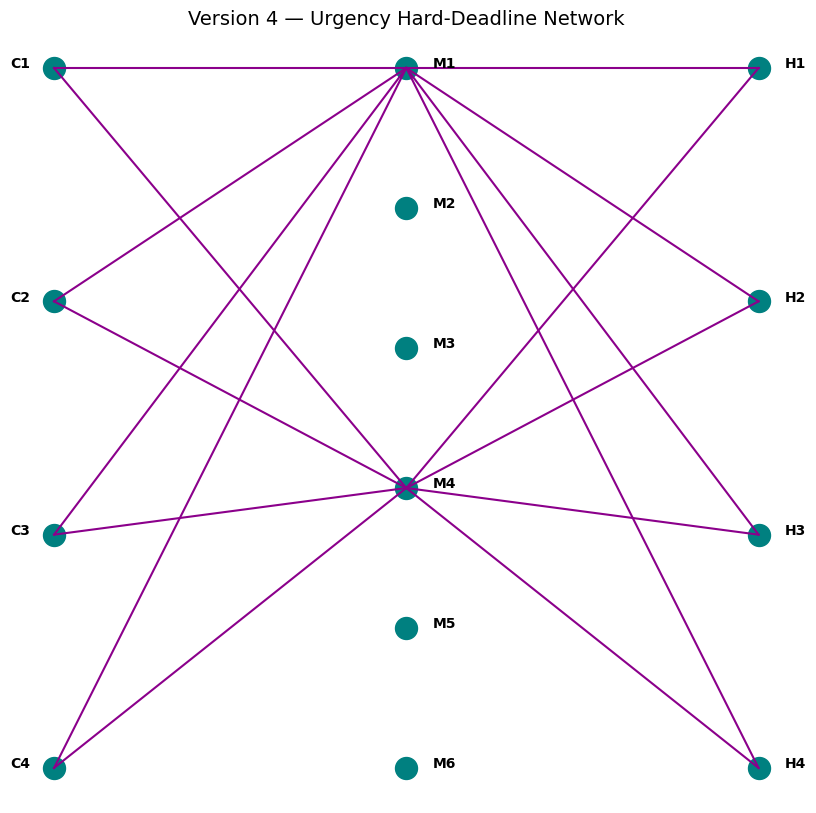

Network diagram saved to v4_network.png


In [8]:
fig = plt.figure(figsize=(10, 10))

Nc = 4
Nm = 6
Nh = 4

leukapheresisY = np.linspace(0.1, 0.9, Nc)
leukapheresisX = 0.1 * np.ones_like(leukapheresisY)
manufacturingY = np.linspace(0.1, 0.9, Nm)
manufacturingX = 0.5 * np.ones_like(manufacturingY)
hospitalY      = np.linspace(0.1, 0.9, Nh)
hospitalX      = 0.9 * np.ones_like(hospitalY)

for c in instance.c:
    for m in instance.m:
        if value(instance.X1[c,m]) != 0:
            plt.plot([leukapheresisX[Nc - instance.c.ord(c)],
                      manufacturingX[Nm - instance.m.ord(m)]],
                     [leukapheresisY[Nc - instance.c.ord(c)],
                      manufacturingY[Nm - instance.m.ord(m)]],
                     color='darkmagenta')

for m in instance.m:
    for h in instance.h:
        if value(instance.X2[m,h]) != 0:
            plt.plot([manufacturingX[Nm - instance.m.ord(m)],
                      hospitalX[Nh - instance.h.ord(h)]],
                     [manufacturingY[Nm - instance.m.ord(m)],
                      hospitalY[Nh - instance.h.ord(h)]],
                     color='darkmagenta')

for i in range(Nc):
    plt.scatter(leukapheresisX[i], leukapheresisY[i], s=250, color='teal')
    plt.text(leukapheresisX[Nc-i-1] - 0.05, leukapheresisY[Nc-i-1],
             'C' + str(i+1), fontweight='bold')

for i in range(Nm):
    plt.scatter(manufacturingX[i], manufacturingY[i], s=250, color='teal')
    plt.text(manufacturingX[Nm-i-1] + 0.03, manufacturingY[Nm-i-1],
             'M' + str(i+1), fontweight='bold')

for i in range(Nh):
    plt.scatter(hospitalX[i], hospitalY[i], s=250, color='teal')
    plt.text(hospitalX[Nh-i-1] + 0.03, hospitalY[Nh-i-1],
             'H' + str(i+1), fontweight='bold')

plt.title('Version 4 — Urgency Hard-Deadline Network', fontsize=14)
plt.axis('off')
fig.savefig('v4_network.png', dpi=150)
plt.show()
print('Network diagram saved to v4_network.png')